In [1]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import mapping
import os

In [4]:
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR = os.path.join(BASE_DIR, 'data')

AOI_PATH = os.path.join(DATA_DIR, 'aoi.geojson')
DEM_PATH = os.path.join(DATA_DIR, 'dem_mosaic.tif')
SLOPE_PATH = os.path.join(DATA_DIR, 'slope.tif')
ASPECT_PATH = os.path.join(DATA_DIR, 'aspect.tif')
TERRAIN_PATH = os.path.join(DATA_DIR, 'terrain.tif')

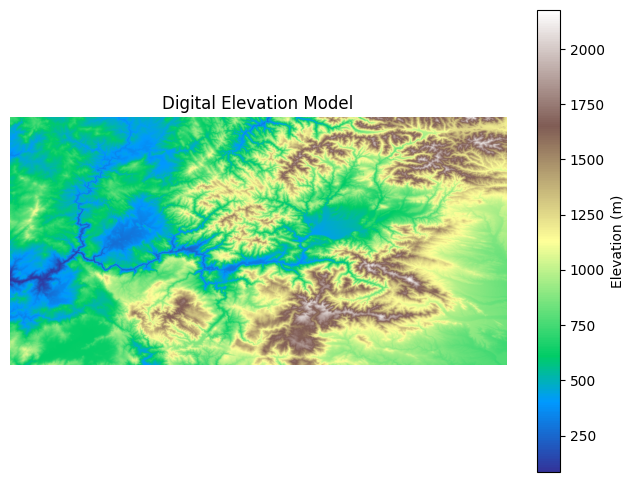

In [6]:
with rasterio.open(DEM_PATH) as src:
    dem = src.read(1)          # first band
    dem_affine = src.transform
    dem_crs = src.crs
    nodata = src.nodata

# Mask NoData values
dem = np.where(dem == nodata, np.nan, dem)

# Plot DEM
plt.figure(figsize=(8, 6))
plt.imshow(dem, cmap="terrain")
plt.colorbar(label="Elevation (m)")
plt.title("Digital Elevation Model")
plt.axis("off")
plt.show()


In [7]:
def calculate_slope(dem, transform, out_path, meta):
    """
    Calculate slope in degrees from DEM
    
    Parameters:
    -----------
    dem : ndarray
        Digital Elevation Model (meters)
        
    Returns:
    --------
    slope : ndarray
        Slope in degrees
    """
    # Pixel size
    dx = transform.a
    dy = -transform.e  # negative because north-up rasters

    # Calculate gradient (rise/run)
    gy, gx = np.gradient(dem) #(dz/dx, dz/dy)
    slope_radians = np.arctan(np.sqrt(gx**2 + gy**2))
    slope_degrees = np.degrees(slope_radians)

    meta.update(
        dytpe=rasterio.float32,
        count=1,
        nodata=np.nan
    )

    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(slope_degrees.astype(np.float32), 1)
    
    return slope_degrees

In [8]:
with rasterio.open(DEM_PATH) as src:
    dem = src.read(1)
    transform = src.transform
    meta = src.meta.copy()

slope = calculate_slope(
    dem,
    transform,
    out_path=SLOPE_PATH,
    meta=meta
)

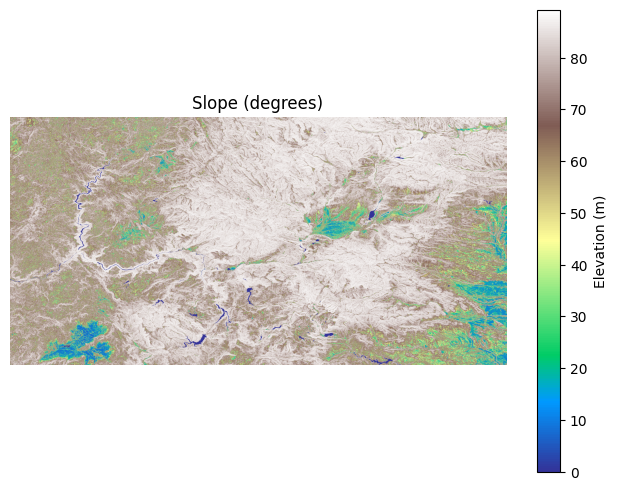

In [9]:
# Plot slope
plt.figure(figsize=(8, 6))
plt.imshow(slope, cmap="terrain")
plt.colorbar(label="Elevation (m)")
plt.title("Slope (degrees)")
plt.axis("off")
plt.show()

## Aspect calculation

Aspect = direction the slope faces (0–360°, clockwise from North).
Required for SCS+C topographic correction.

In [10]:
def calculate_aspect(dem):
    """
    Calculate aspect (slope direction) from DEM.
    
    Returns:
        aspect_degrees : ndarray
            Aspect in degrees, 0-360 clockwise from North.
            Flat pixels (slope~0) get nodata (-1).
    """
    gy, gx = np.gradient(dem)
    
    # arctan2 gives angle from East, counter-clockwise
    # Convert to geographic convention: clockwise from North
    aspect_rad = np.arctan2(-gy, gx)  # math convention
    aspect_deg = np.degrees(aspect_rad)
    
    # Convert: math angle → geographic azimuth
    # math 0° = East  → geo 90°
    # math 90° = North → geo 0°
    aspect_geo = (90.0 - aspect_deg) % 360.0
    
    # Mark flat areas (where gradient ≈ 0) as nodata
    flat = (np.abs(gx) < 1e-8) & (np.abs(gy) < 1e-8)
    aspect_geo[flat] = -1.0
    
    return aspect_geo.astype(np.float32)


## Updated terrain stack (3 bands: DEM + Slope + Aspect)

In [11]:
def terrain_3band(dem_path, slope_path, aoi_geom, out_path):
    """
    Create 3-band terrain GeoTIFF:
        Band 1: DEM (meters)
        Band 2: Slope (degrees)
        Band 3: Aspect (degrees, 0-360 from North)
    """

    # --- Clip DEM ---
    with rasterio.open(dem_path) as src_dem:
        dem_clip, dem_transform = mask(src_dem, aoi_geom, crop=True)
        dem_clip = dem_clip[0].astype(np.float32)
        meta = src_dem.meta.copy()
        meta.update({
            "height": dem_clip.shape[0],
            "width": dem_clip.shape[1],
            "transform": dem_transform,
            "count": 3,  # 3 bands: DEM + slope + aspect
            "dtype": "float32"
        })

    # --- Clip Slope ---
    with rasterio.open(slope_path) as src_slope:
        slope_clip, _ = mask(src_slope, aoi_geom, crop=True)
        slope_clip = slope_clip[0].astype(np.float32)

    # --- Calculate Aspect from clipped DEM ---
    aspect_clip = calculate_aspect(dem_clip)

    # --- Stack 3 bands ---
    terrain_stack = np.stack([dem_clip, slope_clip, aspect_clip], axis=0)

    # --- Write ---
    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(terrain_stack)

    print(f"Terrain saved: {out_path}")
    print(f"  Band 1: DEM (m)")
    print(f"  Band 2: Slope (degrees)")
    print(f"  Band 3: Aspect (degrees from N)")
    print(f"  Shape: {terrain_stack.shape}")

    return terrain_stack, dem_transform


In [14]:
# --- Read AOI geometries ---
aoi_gdf = gpd.read_file(AOI_PATH)
aoi_geom = [feature for feature in aoi_gdf.geometry]

# --- Run 3-band terrain ---
terrain_stack, transform = terrain_3band(
    dem_path=DEM_PATH,
    slope_path=SLOPE_PATH,
    aoi_geom=aoi_geom,
    out_path=TERRAIN_PATH
)


Terrain saved: c:\Repos\ARua_Wildfire\data\terrain.tif
  Band 1: DEM (m)
  Band 2: Slope (degrees)
  Band 3: Aspect (degrees from N)
  Shape: (3, 814, 1234)


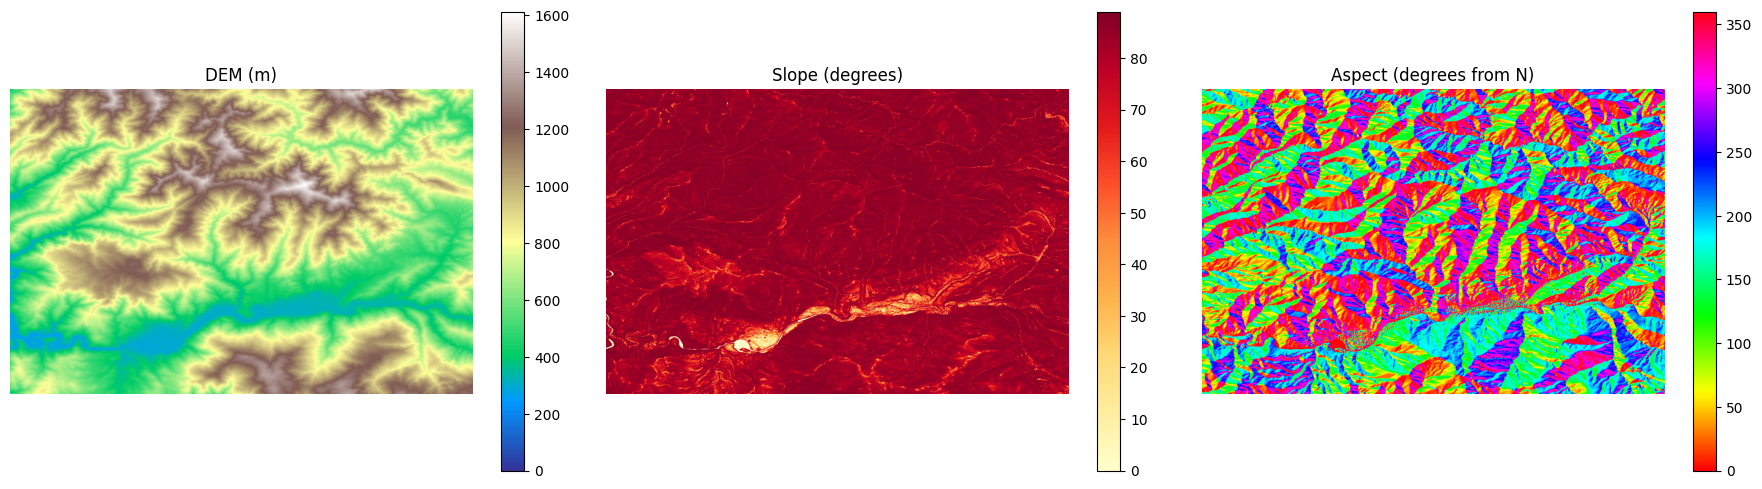

In [15]:
# Plot aspect
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(terrain_stack[0], cmap="terrain")
axes[0].set_title("DEM (m)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(terrain_stack[1], cmap="YlOrRd")
axes[1].set_title("Slope (degrees)")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(terrain_stack[2], cmap="hsv", vmin=0, vmax=360)
axes[2].set_title("Aspect (degrees from N)")
plt.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()
